In [19]:
# Sets up the environment: imports pandas and numpy, loads the dataset,
# and inspects shape, column names, data types, and missing values.
try:
    import pandas as pd
    import numpy as np
    print("Libraries imported successfully.")
except Exception as e:
    print(f"Import error: {e}")
#load dataset
try:
    df = pd.read_csv("/content/train_data.csv")
    print("\nDataset loaded successfully.")
except FileNotFoundError:
    print("Error: train_data.csv not found.")
except Exception as e:
    print(f"Dataset loading error: {e}")
#dataset inspection
try:
    print("\nDataset Shape:")
    print(df.shape)
    print("\nFirst 5 Rows:")
    display(df.head())
    print("\nColumn Names:")
    print(df.columns.tolist())
    print("\nData Types:")
    display(df.dtypes)
    print("\nMissing Values (Top 20):")
    display(
        df.isnull()
          .sum()
          .sort_values(ascending=False)
          .head(20)
    )
except Exception as e:
    print(f"Inspection error: {e}")

Libraries imported successfully.

Dataset loaded successfully.

Dataset Shape:
(153755, 122)

First 5 Rows:


,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,410704,0,Cash loans,F,N,Y,1,157500.0,900000.0,26446.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
1,381230,0,Cash loans,F,N,Y,1,90000.0,733176.0,21438.0,...,0,0,0,0,0.0,0.0,0.0,0.0,2.0,1.0
2,450177,0,Cash loans,F,Y,Y,0,189000.0,1795500.0,62541.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
3,332445,0,Cash loans,M,Y,N,0,175500.0,494550.0,45490.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
4,357429,0,Cash loans,F,Y,Y,0,270000.0,1724688.0,54283.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0



Column Names:
['SK_ID_CURR', 'TARGET', 'NAME_CONTRACT_TYPE', 'CODE_GENDER', 'FLAG_OWN_CAR', 'FLAG_OWN_REALTY', 'CNT_CHILDREN', 'AMT_INCOME_TOTAL', 'AMT_CREDIT', 'AMT_ANNUITY', 'AMT_GOODS_PRICE', 'NAME_TYPE_SUITE', 'NAME_INCOME_TYPE', 'NAME_EDUCATION_TYPE', 'NAME_FAMILY_STATUS', 'NAME_HOUSING_TYPE', 'REGION_POPULATION_RELATIVE', 'DAYS_BIRTH', 'DAYS_EMPLOYED', 'DAYS_REGISTRATION', 'DAYS_ID_PUBLISH', 'OWN_CAR_AGE', 'FLAG_MOBIL', 'FLAG_EMP_PHONE', 'FLAG_WORK_PHONE', 'FLAG_CONT_MOBILE', 'FLAG_PHONE', 'FLAG_EMAIL', 'OCCUPATION_TYPE', 'CNT_FAM_MEMBERS', 'REGION_RATING_CLIENT', 'REGION_RATING_CLIENT_W_CITY', 'WEEKDAY_APPR_PROCESS_START', 'HOUR_APPR_PROCESS_START', 'REG_REGION_NOT_LIVE_REGION', 'REG_REGION_NOT_WORK_REGION', 'LIVE_REGION_NOT_WORK_REGION', 'REG_CITY_NOT_LIVE_CITY', 'REG_CITY_NOT_WORK_CITY', 'LIVE_CITY_NOT_WORK_CITY', 'ORGANIZATION_TYPE', 'EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3', 'APARTMENTS_AVG', 'BASEMENTAREA_AVG', 'YEARS_BEGINEXPLUATATION_AVG', 'YEARS_BUILD_AVG', 'COMMON

,0
SK_ID_CURR,int64
TARGET,int64
NAME_CONTRACT_TYPE,object
CODE_GENDER,object
FLAG_OWN_CAR,object
...,...
AMT_REQ_CREDIT_BUREAU_DAY,float64
AMT_REQ_CREDIT_BUREAU_WEEK,float64
AMT_REQ_CREDIT_BUREAU_MON,float64
AMT_REQ_CREDIT_BUREAU_QRT,float64



Missing Values (Top 20):


,0
COMMONAREA_AVG,107523
COMMONAREA_MODE,107523
COMMONAREA_MEDI,107523
NONLIVINGAPARTMENTS_MEDI,106918
NONLIVINGAPARTMENTS_MODE,106918
NONLIVINGAPARTMENTS_AVG,106918
LIVINGAPARTMENTS_AVG,105193
LIVINGAPARTMENTS_MODE,105193
LIVINGAPARTMENTS_MEDI,105193
FONDKAPREMONT_MODE,105177


Visualization libraries loaded.

Target Counts:
TARGET
0    141343
1     12412
Name: count, dtype: int64

Target Percentages:
TARGET
0    91.93
1     8.07
Name: proportion, dtype: float64


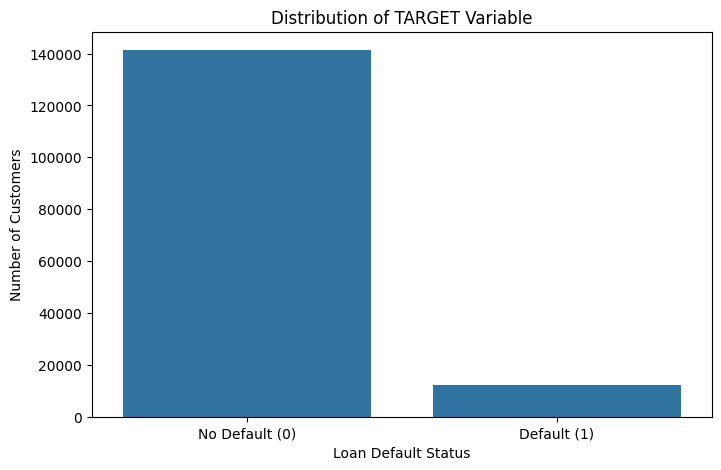

In [20]:
# Import visualization libraries, summarizes TARGET class counts and percentages,
# and plot the distribution to reveal class imbalance between default and non default.

#analyze target variables
try:
    import matplotlib.pyplot as plt
    import seaborn as sns
    print("Visualization libraries loaded.")
except Exception as e:
    print(f"Import error: {e}")
try:
    target_counts = df['TARGET'].value_counts()
    print("\nTarget Counts:")
    print(target_counts)
    print("\nTarget Percentages:")
    print(
        round(
            df['TARGET'].value_counts(normalize=True) * 100,
            2
        )
    )
except Exception as e:
    print(f"Target summary error: {e}")
# plot target count
try:
    plt.figure(figsize=(8, 5))
    sns.countplot(x=df['TARGET'])
    plt.title("Distribution of TARGET Variable")
    plt.xlabel("Loan Default Status")
    plt.ylabel("Number of Customers")
    plt.xticks(
        ticks=[0, 1],
        labels=[
            "No Default (0)",
            "Default (1)"
        ]
    )
    plt.show()
except Exception as e:
    print(f"Plotting error: {e}")


# TARGET VARIABLE INTERPRETATION
The dataset is highly imbalanced:
 - TARGET = 0 --> ~92%
 - TARGET = 1 --> ~8%
This means most customers successfully repaid loans,while only a small proportion experienced payment difficulties.

# Implications for predictive modeling:
1. Accuracy alone may be misleading because a model predicting mostly non-defaults could still achieve high accuracy.
2. Metrics such as:
   - ROC-AUC
   - Precision
   - Recall
   - F1-score

become more important.

3. Class imbalance techniques may be required:
    - class weighting
    - oversampling
    - SMOTE
    - undersampling

This imbalance is common in real world credit risk datasets.


# MISSING VALUE OBSERVATION
Some selected variables, particularly:
 - EXT_SOURCE_1
 - EXT_SOURCE_2
 - EXT_SOURCE_3

contain missing values.

Missing data is important because it may:
 - reduce model performance
 - introduce bias
 - require imputation strategies

Despite missing values, these variables were retained because they showed the strongest relationship with the target variable and likely contain highly valuable predictive information.

In [21]:
# Encode categorical variables numerically using LabelEncoder, then compute
# absolute Pearson correlation of all features with TARGET to rank predictive relevance.

#feature selection using correlation
try:
    from sklearn.preprocessing import LabelEncoder
    print("LabelEncoder imported successfully.")
except Exception as e:
    print(f"Import error: {e}")
try:
    # create copy of data
    df_encoded = df.copy()
    print("Dataset copied successfully.")
except Exception as e:
    print(f"Copy error: {e}")
try:
  #encode categorical variables
    encoder = LabelEncoder()
    categorical_columns = df_encoded.select_dtypes(
        include=['object']
    ).columns
    print(f"\nCategorical Columns Found: {len(categorical_columns)}")
    for col in categorical_columns:
        try:
            df_encoded[col] = encoder.fit_transform(
                df_encoded[col].astype(str)
            )
        except Exception as inner_error:
            print(f"Encoding failed for {col}: {inner_error}")
    print("\nCategorical encoding completed.")
except Exception as e:
    print(f"Encoding process error: {e}")
#compute correlation
try:
    correlations = (
        df_encoded.corr(numeric_only=True)['TARGET']
        .drop('TARGET')
        .abs()
        .sort_values(ascending=False)
    )
    print("\nTop 20 Variables Most Related to TARGET:\n")
    display(correlations.head(20))
except Exception as e:
    print(f"Correlation analysis error: {e}")

LabelEncoder imported successfully.
Dataset copied successfully.

Categorical Columns Found: 16

Categorical encoding completed.

Top 20 Variables Most Related to TARGET:



,TARGET
EXT_SOURCE_3,0.179497
EXT_SOURCE_2,0.159253
EXT_SOURCE_1,0.157721
DAYS_BIRTH,0.077244
REGION_RATING_CLIENT_W_CITY,0.059529
REGION_RATING_CLIENT,0.057593
NAME_EDUCATION_TYPE,0.056708
CODE_GENDER,0.053401
DAYS_LAST_PHONE_CHANGE,0.052529
REG_CITY_NOT_WORK_CITY,0.050319


Top10 variables selected successfully.

Selected Feature Correlations:



,TARGET
DAYS_EMPLOYED,0.045655
NAME_INCOME_TYPE,0.047867
DAYS_LAST_PHONE_CHANGE,0.052529
CODE_GENDER,0.053401
NAME_EDUCATION_TYPE,0.056708
REGION_RATING_CLIENT_W_CITY,0.059529
DAYS_BIRTH,0.077244
EXT_SOURCE_1,0.157721
EXT_SOURCE_2,0.159253
EXT_SOURCE_3,0.179497


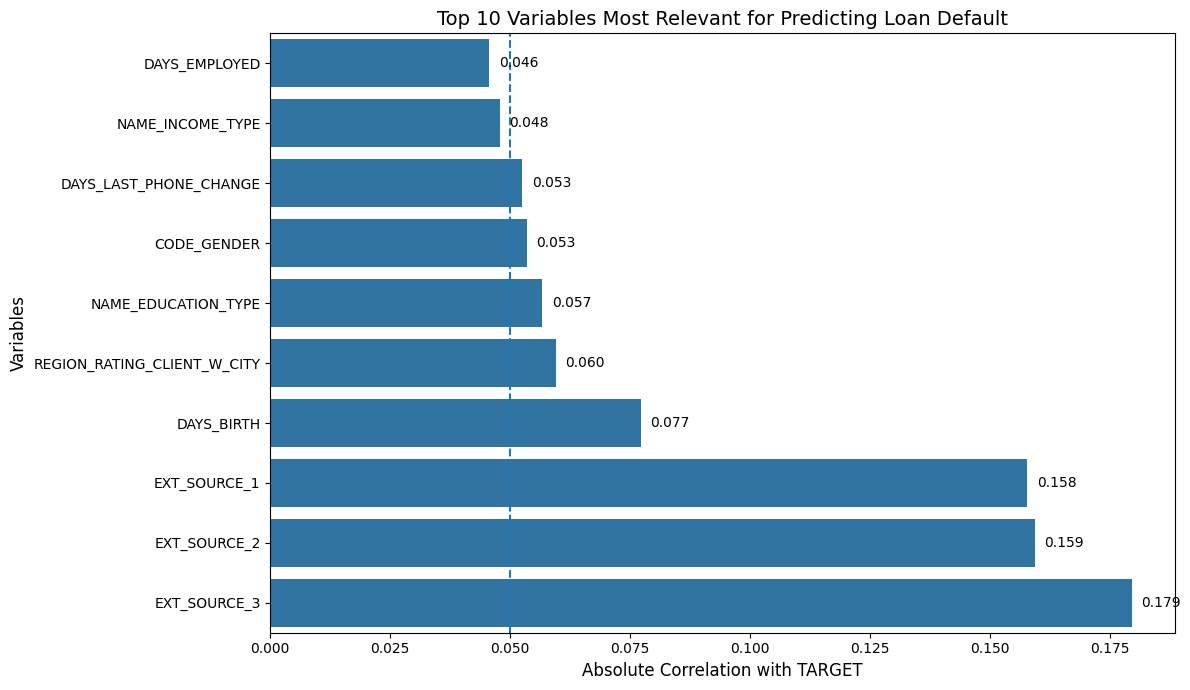

In [22]:
# Define the 10 selected features, extracts their correlations, and plot a
# horizontal bar chart with value labels and a 0.05 reference line for relevance threshold.

#top 10 variable selection
try:
    selected_features = [
        'EXT_SOURCE_3',
        'EXT_SOURCE_2',
        'EXT_SOURCE_1',
        'DAYS_BIRTH',
        'REGION_RATING_CLIENT_W_CITY',
        'NAME_EDUCATION_TYPE',
        'CODE_GENDER',
        'DAYS_LAST_PHONE_CHANGE',
        'NAME_INCOME_TYPE',
        'DAYS_EMPLOYED'
    ]
    print("Top10 variables selected successfully.")
except Exception as e:
    print(f"Feature selection definition error: {e}")
#create correlation table
try:
    top10_corr = correlations[selected_features]
    top10_corr = top10_corr.sort_values(ascending=True)
    print("\nSelected Feature Correlations:\n")
    display(top10_corr)
except Exception as e:
    print(f"Correlation table error: {e}")
# plot 10 variables
try:
    import matplotlib.pyplot as plt
    import seaborn as sns
    plt.figure(figsize=(12, 7))
    sns.barplot(
        x=top10_corr.values,
        y=top10_corr.index
    )
    #dashed reference line indicating a practical threshold for moderate feature relevance
    plt.axvline(
      x=0.05,
      linestyle='--'
    )

    for index, value in enumerate(top10_corr.values):

      plt.text(
        value + 0.002,
        index,
        f"{value:.3f}",
        va='center'
      )
    plt.title(
        "Top 10 Variables Most Relevant for Predicting Loan Default",
        fontsize=14
    )
    plt.xlabel(
        "Absolute Correlation with TARGET",
        fontsize=12
    )
    plt.ylabel(
        "Variables",
        fontsize=12
    )
    plt.tight_layout()
    plt.show()
except Exception as e:
    print(f"Visualization error: {e}")

# NOTE:
DAYS_EMPLOYED was selected despite ranking lower
than REG_CITY_NOT_WORK_CITY because employment
stability has stronger business relevance and
clearer interpretability in credit risk modeling.
Employment duration is directly connected to:
  - income stability
  - repayment capability
  - long-term financial reliability
Therefore, it is considered more meaningfulfor predictive modeling.

In [23]:
# Converts DAYS_BIRTH and DAYS_EMPLOYED from negative days to readable positive years,
# capping EMPLOYED_YEARS at 50 to prevent extreme outliers from skewing the plots.
try:
    df['AGE_YEARS'] = abs(df['DAYS_BIRTH']) / 365
    df['EMPLOYED_YEARS'] = (
        abs(df['DAYS_EMPLOYED']) / 365
    ).clip(upper=50)
    df['PHONE_CHANGE_YEARS'] = abs(df['DAYS_LAST_PHONE_CHANGE']) / 365
except Exception as e:
    print(f"Conversion error: {e}")

FEATURE: EXT_SOURCE_3
Anonymized external bureau score — likely sourced from credit agencies — summarizing a customer's historical borrowing and repayment behavior into a normalized score. Lower scores are strongly associated with higher default probability, making this the single most predictive variable in the dataset.
Observation: Defaulters show visibly lower scores,the median is notably shifted downward compared to non defaulters.


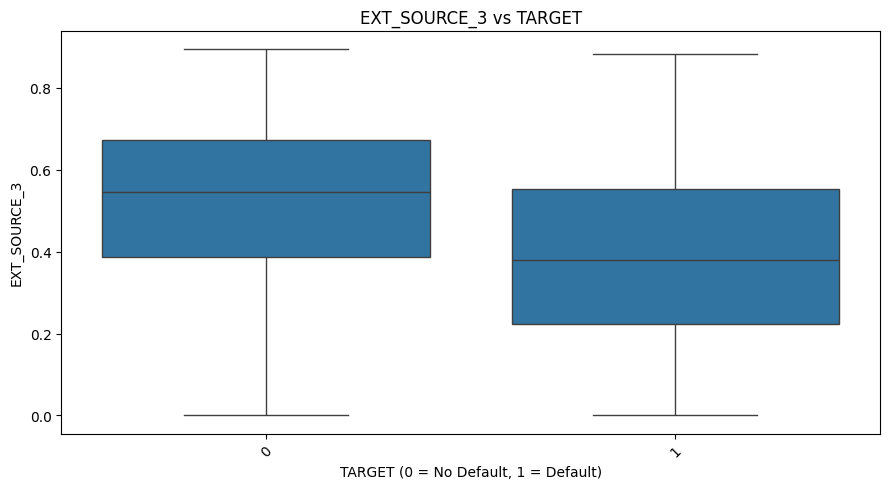

FEATURE: EXT_SOURCE_2
A second external bureau score measuring financial credibility and repayment reliability. Like EXT_SOURCE_3, it aggregates historical credit behavior. Despite missing values in ~30% of rows, it is retained due to its strong predictive relationship with TARGET.
Observation: Similar pattern to EXT_SOURCE_3, non defaulters cluster at higher score values.


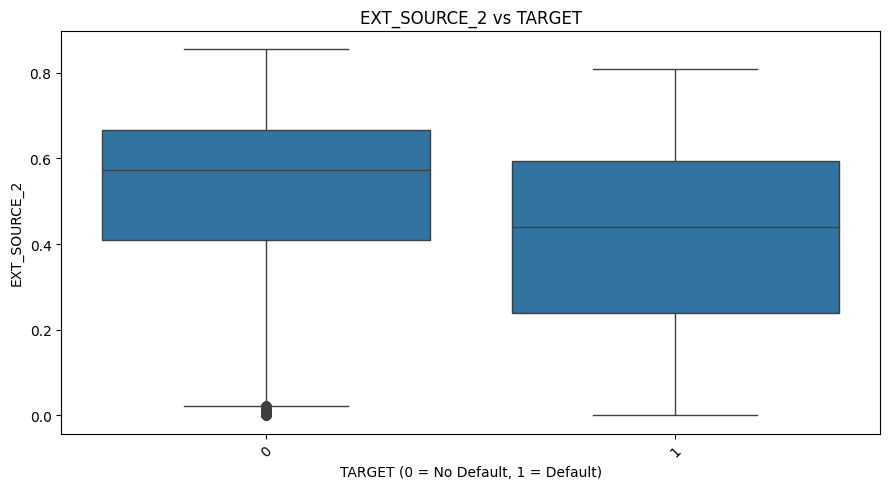

FEATURE: EXT_SOURCE_1
A third external risk indicator connected to historical financial behavior. All three EXT_SOURCE variables collectively form the strongest predictive signal in the dataset. Missing value imputation (median or model-based) will be required before modeling.
Observation: Consistent with the other EXT_SOURCE variables, lower scores align with higher default rates.


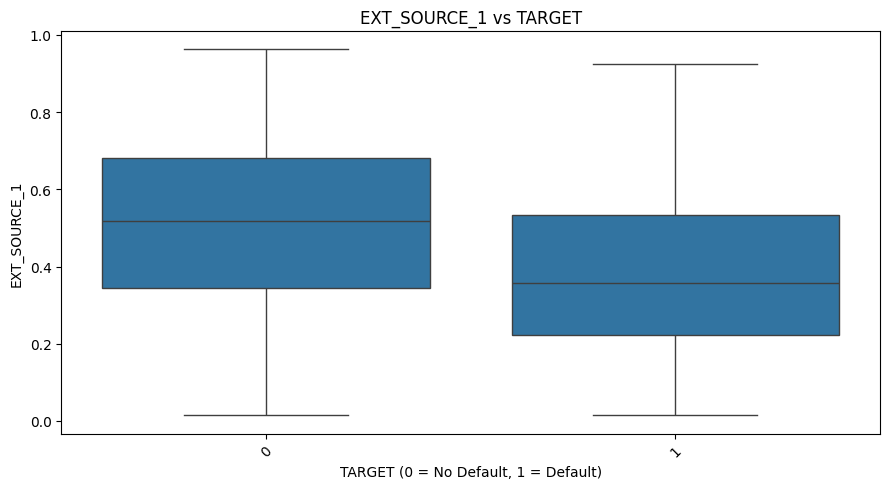

FEATURE: DAYS_BIRTH
Represents customer age. Age can influence employment stability and repayment capability.
Observation: Defaulters tend to be younger, the median age for defaults is lower, suggesting younger customers carry more risk.


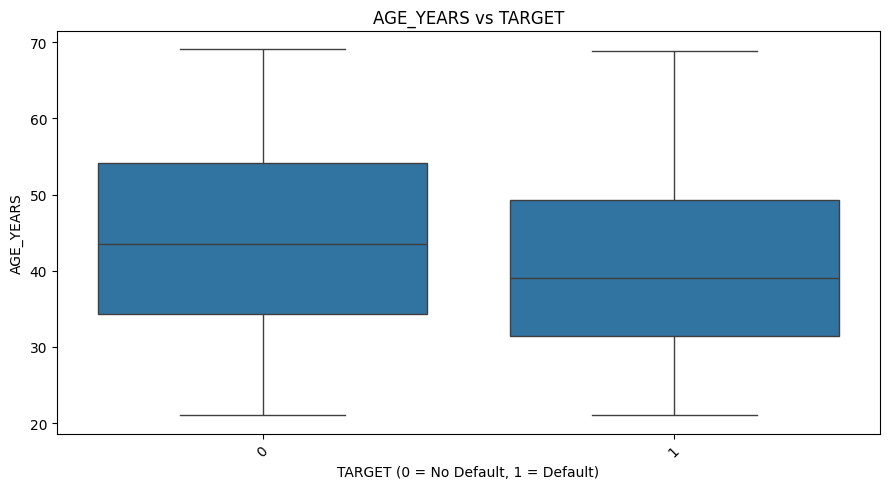

FEATURE: REGION_RATING_CLIENT_W_CITY
Regional risk rating considering city level socioeconomic factors. Certain regions may historically exhibit higher loan default risk.
Observation: Higher region ratings are associated with higher default rates, indicating regional socioeconomic risk is meaningful.


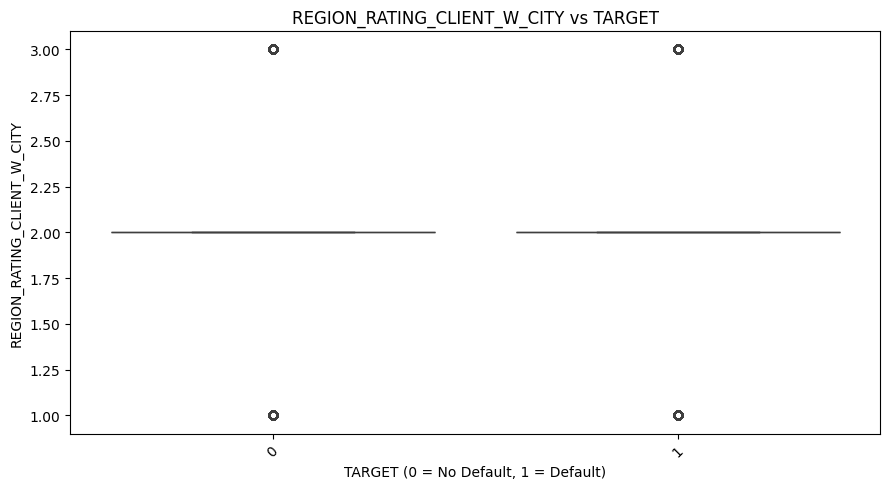

FEATURE: NAME_EDUCATION_TYPE
Education level may influence employment opportunities, earning potential, and long-term financial stability.
Observation: Lower secondary education shows the highest default rate; academic degree holders show the lowest education level tracks clearly with repayment.


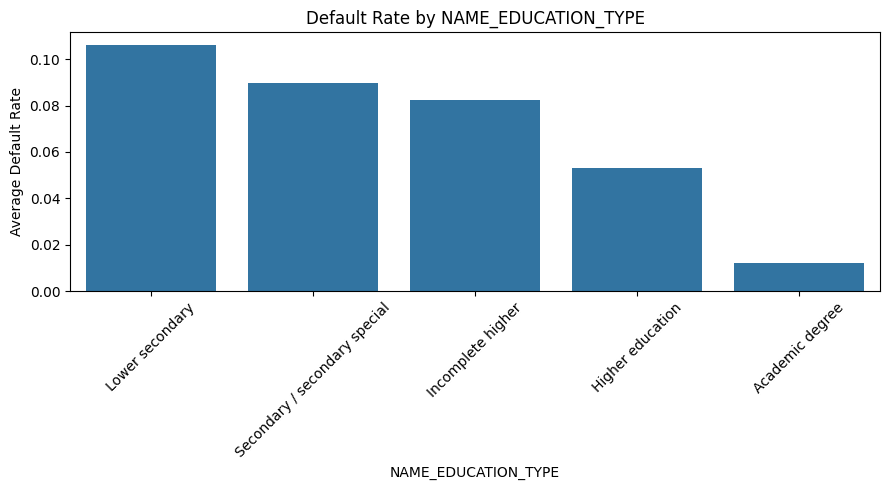

FEATURE: CODE_GENDER
Demographic variable that may capture behavioral and socioeconomic differences associated with repayment patterns.
Observation: Male customers show a higher average default rate than female customers in this dataset.


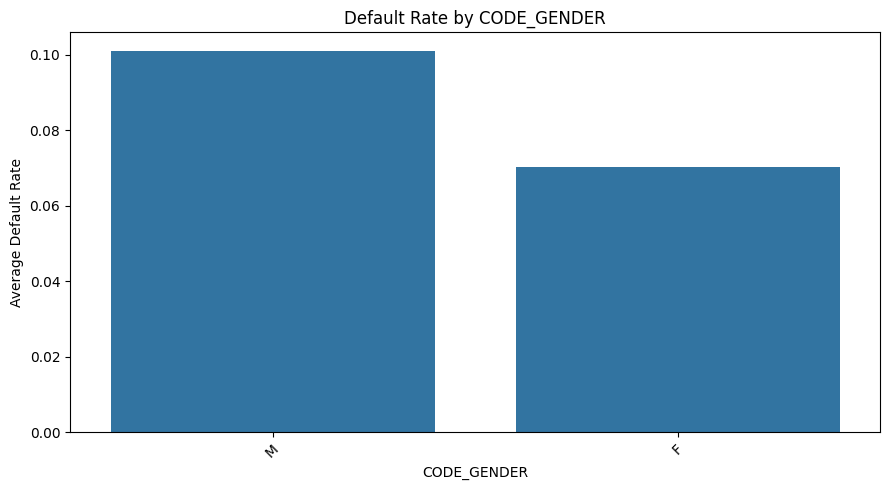

FEATURE: DAYS_LAST_PHONE_CHANGE
Frequent or recent phone changes may indicate financial instability, changing living conditions, or inconsistent customer behavior.
Observation: Defaulters show more recent phone changes on average, consistent with financial instability signals.


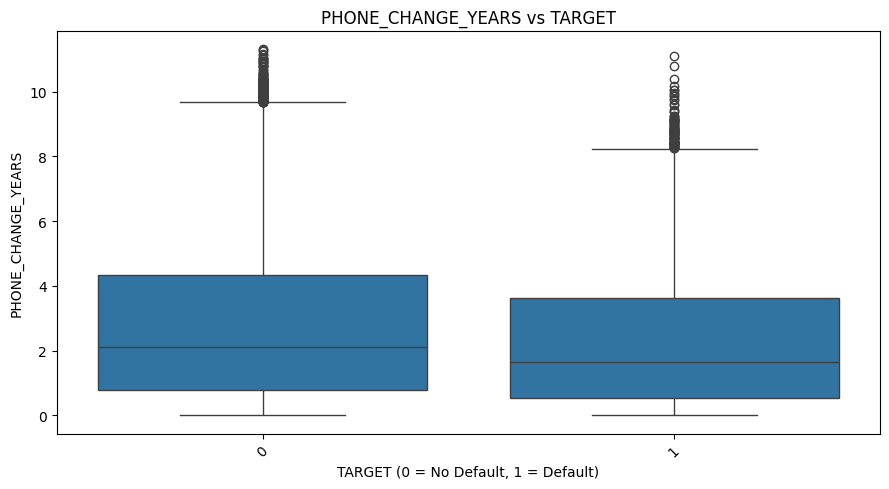

FEATURE: NAME_INCOME_TYPE
Income type reflects employment category and financial stability, both of which strongly influence repayment capability.
Observation: Working and commercial associate categories dominate the dataset; maternity leave is a small group anomaly requiring verification.

 NOTE: The 'Maternity leave' category shows an unusually high default rate (~65%). This is likely a statistical artifact from a very small sample size, not a true signal. Group sizes should be verified before modeling,small categories may need merging or dropping.


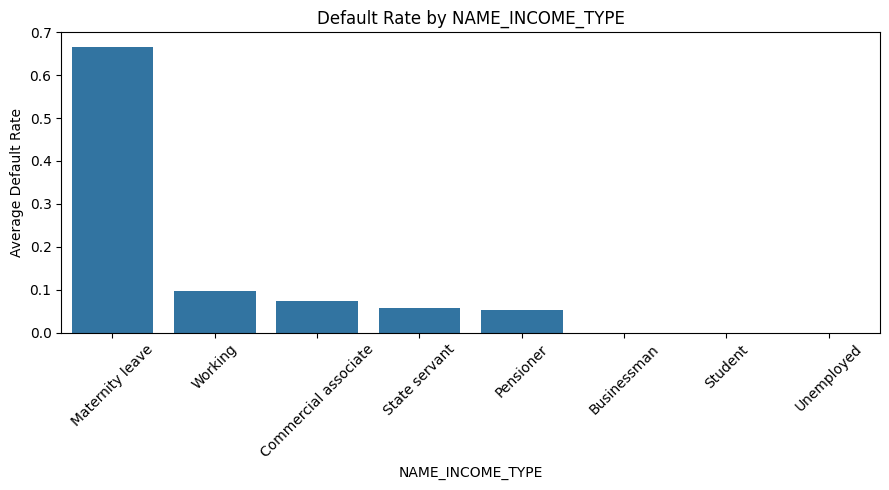

FEATURE: DAYS_EMPLOYED
Employment duration is strongly connected to income consistency, job stability, and repayment reliability.
Observation: Non-defaulters have longer employment durations on average, supporting the employment stability hypothesis.


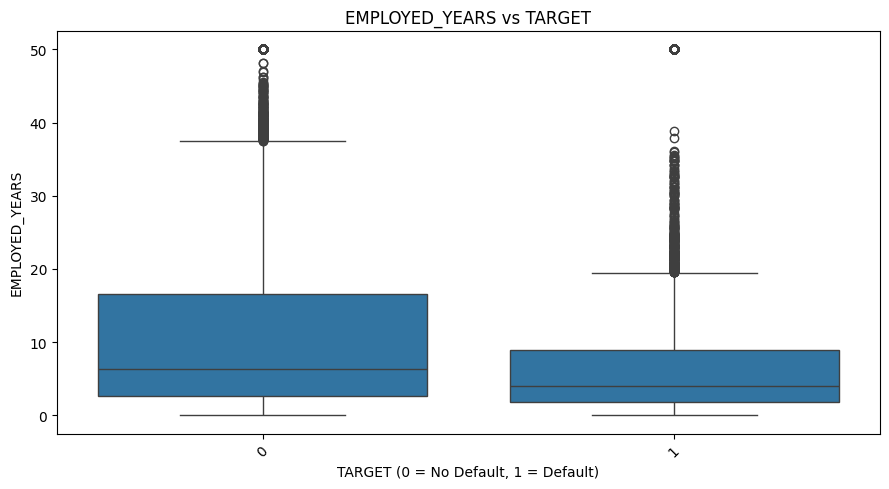

In [24]:
# Plots each selected feature individually against TARGET: boxplots for numeric variables
# and average default rate bar charts for categoricals with an explanation per feature.

# feature by feature analysis
try:
    import matplotlib.pyplot as plt
    import seaborn as sns
except Exception as e:
    print(f"Import error: {e}")
# feature explanations
feature_explanations = {
   'EXT_SOURCE_3':
    'Anonymized external bureau score — likely sourced from credit agencies — '
    'summarizing a customer\'s historical borrowing and repayment behavior into '
    'a normalized score. Lower scores are strongly associated with higher default '
    'probability, making this the single most predictive variable in the dataset.',
  'EXT_SOURCE_2':
    'A second external bureau score measuring financial credibility and repayment '
    'reliability. Like EXT_SOURCE_3, it aggregates historical credit behavior. '
    'Despite missing values in ~30% of rows, it is retained due to its strong '
    'predictive relationship with TARGET.',
  'EXT_SOURCE_1':
    'A third external risk indicator connected to historical financial behavior. '
    'All three EXT_SOURCE variables collectively form the strongest predictive '
    'signal in the dataset. Missing value imputation (median or model-based) '
    'will be required before modeling.',
    'DAYS_BIRTH':
        'Represents customer age. Age can influence employment stability and repayment capability.',
    'REGION_RATING_CLIENT_W_CITY':
        'Regional risk rating considering city level socioeconomic factors. Certain regions may historically exhibit higher loan default risk.',
    'NAME_EDUCATION_TYPE':
        'Education level may influence employment opportunities, earning potential, and long-term financial stability.',
    'CODE_GENDER':
        'Demographic variable that may capture behavioral and socioeconomic differences associated with repayment patterns.',
    'DAYS_LAST_PHONE_CHANGE':
        'Frequent or recent phone changes may indicate financial instability, changing living conditions, or inconsistent customer behavior.',
    'NAME_INCOME_TYPE':
        'Income type reflects employment category and financial stability, both of which strongly influence repayment capability.',
    'DAYS_EMPLOYED':
        'Employment duration is strongly connected to income consistency, job stability, and repayment reliability.'
}

feature_observations = {
    'EXT_SOURCE_3': 'Observation: Defaulters show visibly lower scores,the median is notably shifted downward compared to non defaulters.',
    'EXT_SOURCE_2': 'Observation: Similar pattern to EXT_SOURCE_3, non defaulters cluster at higher score values.',
    'EXT_SOURCE_1': 'Observation: Consistent with the other EXT_SOURCE variables, lower scores align with higher default rates.',
    'DAYS_BIRTH': 'Observation: Defaulters tend to be younger, the median age for defaults is lower, suggesting younger customers carry more risk.',
    'REGION_RATING_CLIENT_W_CITY': 'Observation: Higher region ratings are associated with higher default rates, indicating regional socioeconomic risk is meaningful.',
    'NAME_EDUCATION_TYPE': 'Observation: Lower secondary education shows the highest default rate; academic degree holders show the lowest education level tracks clearly with repayment.',
    'CODE_GENDER': 'Observation: Male customers show a higher average default rate than female customers in this dataset.',
    'DAYS_LAST_PHONE_CHANGE': 'Observation: Defaulters show more recent phone changes on average, consistent with financial instability signals.',
    'NAME_INCOME_TYPE': 'Observation: Working and commercial associate categories dominate the dataset; maternity leave is a small group anomaly requiring verification.',
    'DAYS_EMPLOYED': 'Observation: Non-defaulters have longer employment durations on average, supporting the employment stability hypothesis.'
}
#individual feature plots
try:
    for feature in selected_features:
        print(f"FEATURE: {feature}")
        print(feature_explanations[feature])
        print(feature_observations[feature])
        plt.figure(figsize=(9, 5))
        plot_feature = feature
        if feature == 'DAYS_BIRTH':
            plot_feature = 'AGE_YEARS'
        elif feature == 'DAYS_EMPLOYED':
            plot_feature = 'EMPLOYED_YEARS'
        elif feature == 'DAYS_LAST_PHONE_CHANGE':
            plot_feature = 'PHONE_CHANGE_YEARS'
        #numeric features
        if pd.api.types.is_numeric_dtype(df[feature]):
            sns.boxplot(
                x=df['TARGET'],
                y=df[plot_feature]
            )
            plt.title(f"{plot_feature} vs TARGET")
            plt.xlabel(
                "TARGET (0 = No Default, 1 = Default)"
            )
            plt.ylabel(plot_feature)
        #categorical features
        else:
            category_default_rate = (

              df.groupby(feature)['TARGET']
              .mean()
            .sort_values(ascending=False)
            )
            sns.barplot(
              x=category_default_rate.index,
              y=category_default_rate.values
            )
            plt.title(
              f"Default Rate by {feature}"
            )
            plt.ylabel(
            "Average Default Rate"
            )
             # Anomaly note for NAME_INCOME_TYPE
            if feature == 'NAME_INCOME_TYPE':
                print(
                    "\n NOTE: The 'Maternity leave' category shows an unusually high "
                    "default rate (~65%). This is likely a statistical artifact from a very "
                    "small sample size, not a true signal. Group sizes should be verified "
                    "before modeling,small categories may need merging or dropping."
                )

        plt.xticks(rotation=45)
        plt.tight_layout()
        plt.show()
except Exception as e:
    print(f"Feature analysis error: {e}")

# OVERALL FEATURE INTERPRETATION
The selected variables collectively capture multiple dimensions of customer credit risk.
These variables can be grouped into four major categories:

1. External Creditworthiness Indicators  
   EXT_SOURCE_1, EXT_SOURCE_2, and EXT_SOURCE_3 are anonymized scores sourced
   from external credit bureaus, aggregating a customer's historical borrowing
   and repayment behavior into a single normalized value. These showed the
   strongest correlation with TARGET (up to 0.179), confirming that external
   credit history is the most predictive dimension of loan default risk.  
   Important caveat: all three contain significant missing values (~30-40% of rows) and will require imputation before modeling. Despite this, they are retained due to their superior predictive value.
2. Demographic and Socioeconomic Factors
   DAYS_BIRTH, CODE_GENDER, and NAME_EDUCATION_TYPE capture demographic and
   socioeconomic characteristics.
   These variables may influence:
   - employment opportunities
   - income stability
   - long-term financial behavior

3. Stability and Behavioral Indicators
   DAYS_EMPLOYED and DAYS_LAST_PHONE_CHANGE
   represent employment consistency and personal
   stability.Customers with stable employment and fewer,behavioral disruptions are generally less likely to experience repayment difficulties.
4. Regional and Income Risk Factors
   REGION_RATING_CLIENT_W_CITY and NAME_INCOME_TYPE capture geographic and financial risk patterns. Certain regions and income categories may historically exhibit higher default rates due to economic conditions or employment instability.

Overall, the selected variables provide a balanced representation of:
   - financial credibility
   - demographic characteristics
   - employment stability
   - regional socioeconomic risk
   - behavioral consistency
Together, these variables form a meaningful and
interpretable foundation for predictive modeling
of loan default risk.
